# LC09 — Time series models: a SARIMA baseline for Svedala (self-paced, ~45 min)

Before anyone is allowed to throw machine learning at a forecasting problem (Module 3), they earn the right by building the classical baseline it must beat. This notebook fits a seasonal ARIMA to the Svedala ZON_MITT load and — more importantly — evaluates it the only honest way: **walk-forward, against persistence**. Lab 7 repeats this working method on your own Lab 6 series; material here appears in **Quiz 3**.

**How to use this notebook:** run the cells top to bottom, one at a time. Every code cell has a note above it saying what it is for and what you should see; the numbers quoted are the ones the course series produces. If what you see differs, stop and ask your pod.

## 0. Before you start: opening the notebook on your laptop

Local, not Colab — it reads the course dataset from the repository. From a terminal with your workbook's venv active (the Lab 1 one; `statsmodels` is in it):

```bash
pip install jupyterlab            # once; a tool for you, not a dependency of the toolbox
cd <path to your clone of>/course-material/notebooks
jupyter lab                       # opens in your browser; double-click LC09_sarima_baseline.ipynb
```

Start Jupyter *inside* `notebooks/` — the guard cell checks that. Shift+Enter runs a cell; the kernel offered, "Python 3 (ipykernel)", is your venv's Python when Jupyter was started from the activated venv.

### 0.1 Setup

`%pip install` installs into the notebook's own Python; in the course venv every one of these is already there at its pinned version, so nothing is upgraded. **What you see:** one "Note: you may need to restart the kernel…" line, or nothing.

In [1]:
# Install exactly what this notebook uses.
%pip install pandas numpy statsmodels matplotlib pyarrow --quiet


Note: you may need to restart the kernel to use updated packages.


The guard: `assert` stops here with a clear message if `../data` is missing. **What you see:** nothing — good.

In [2]:
from pathlib import Path
# Guard: this notebook expects to run from the notebooks/ folder of a clone of
# the course repository — the datasets live one level up in ../data/.
# Failing here, early and clearly, beats a confusing FileNotFoundError later.
assert Path("../data").exists(), (
    "Course data folder not found. Clone KTH-EG2140/course-material and open "
    "this notebook from its notebooks/ folder.")

### 0.2 The series

`warnings.filterwarnings("ignore")` silences library warnings for the rest of the notebook — statsmodels prints several per fit, and they would bury the outputs you need to read. The one warning worth knowing about is "no frequency information": the models want to know the series is strictly hourly, and `y.asfreq("h")` tells pandas exactly that (it would insert missing hours as gaps; there are none after the interpolation). `interpolate(limit=3).dropna()` is LC7's short-gap repair in its quick form; this column has no gaps at all, so the line changes nothing — it is the habit, kept. **What you see:** a year of `ZON_MITT` load in MW — high in winter, low in summer, a fuzzy band because every day has its daily swing.

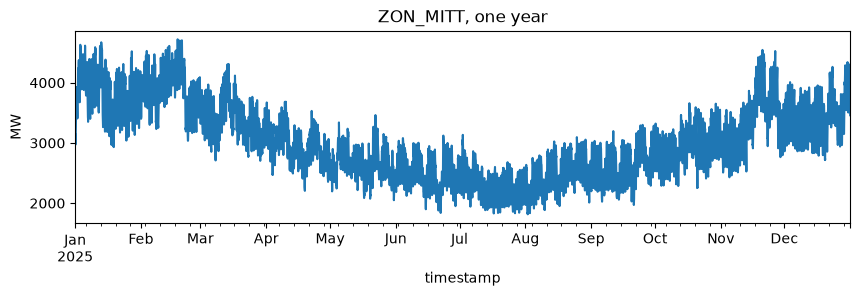

In [3]:
import warnings; warnings.filterwarnings("ignore")   # statsmodels is chatty; see the note above
import numpy as np, pandas as pd
df = pd.read_parquet("../data/svedala-year/svedala_hourly.parquet")
y = df["ZON_MITT"].interpolate(limit=3).dropna()
y = y.asfreq("h")          # tell pandas the series is strictly hourly - the models need to know
ax = y.plot(figsize=(10,2.5), title="ZON_MITT, one year"); ax.set_ylabel("MW");

## 1. Look for structure: the ACF

A load series is nothing but structure — daily cycle, weekly cycle, weather trend. The *autocorrelation function* (ACF) shows it directly: for each lag *k* it gives the correlation between the series and itself shifted by *k* hours, so a value near 1 at lag 24 means "this hour looks like the same hour yesterday".

### 1.1 Reading an ACF

`plot_acf(y, lags=72)` draws the ACF for lags 0 to 72. `y.diff(24)` is each hour minus the same hour the day before — the *seasonal difference* — and `plot_acf` of that shows what structure is left once the daily cycle is removed. `plt.subplots(1, 2)` makes two panels side by side; `plt.tight_layout()` stops their labels overlapping. **What you see:** left, a wave that peaks again at lag 24 and lag 48 — the daily cycle is the dominant structure. Right, after subtracting yesterday: no wave any more; the bars start high (about 0.95 at lag 1) and fall in a straight line to zero around lag 23 — the differenced series still resembles its own recent past, hour to hour — and a dip below zero around lag 48, an echo of the subtraction itself. That remaining short-range structure is what the ARMA terms model.

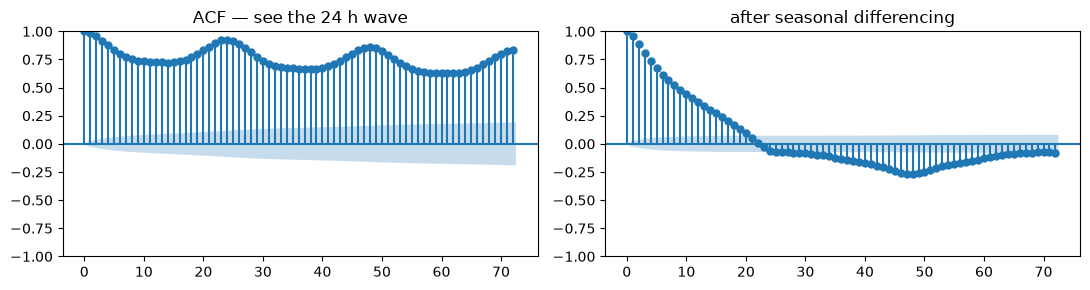

In [4]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
plot_acf(y, lags=72, ax=ax[0]); ax[0].set_title("ACF — see the 24 h wave")
plot_acf(y.diff(24).dropna(), lags=72, ax=ax[1]); ax[1].set_title("after seasonal differencing")
plt.tight_layout()

The 24-hour wave dominates — so the model must contain it. That is what the *seasonal* part of SARIMA(p,d,q)(P,D,Q)ₛ does: model the change **from yesterday's same hour**, then let ARMA terms mop up what remains. The letters: *p* autoregressive terms (today's value depends on the previous values), *d* differences (how many times the series is subtracted from its own past to make it level), *q* moving-average terms (today's value depends on the previous errors); capital P, D, Q are the same three at the seasonal lag *s* = 24. "ARMA" is just AR and MA together.

## 2. Fit — on six weeks, honestly split

Never fit on data you will evaluate on. Train: six winter weeks. Test: the week after.

### 2.1 The fit

`train` and `test` are date-string slices, both ends included, as in LC6: six weeks of winter, then one week. `SARIMAX(train, order=(1,0,1), seasonal_order=(1,1,1,24))` names the model: one autoregressive term (yesterday's value influences today), no plain differencing, one moving-average term (yesterday's error does too), and the same three at the seasonal lag of 24 hours with one seasonal difference — the `diff(24)` you just plotted. The two `enforce_*=False` flags relax two mathematical conditions (that the model's memory of the past fades, in both directions) which the estimator otherwise insists on; on a short window the fit is better behaved without them. `model.fit(disp=False)` estimates the coefficients without a progress printout; `fit.summary().tables[0]` shows the first table of the summary only.

**What you see:** a table whose lines to read are `Dep. Variable: ZON_MITT`, `No. Observations: 984` (41 days × 24 hours) and `Model: SARIMAX(1, 0, 1)x(1, 1, 1, 24)`; the rest (log likelihood, AIC, `Covariance Type: opg`) is fit bookkeeping — AIC comes back in Lab 7 as one way to compare candidates. The fit takes a few seconds.

In [5]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
train = y.loc["2025-01-06":"2025-02-15"]
test  = y.loc["2025-02-16":"2025-02-22"]
model = SARIMAX(train, order=(1,0,1), seasonal_order=(1,1,1,24),
                enforce_stationarity=False, enforce_invertibility=False)
fit = model.fit(disp=False)
print(fit.summary().tables[0])

                                     SARIMAX Results                                      
Dep. Variable:                           ZON_MITT   No. Observations:                  984
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 24)   Log Likelihood               -4944.651
Date:                            Fri, 11 Sep 2026   AIC                           9899.301
Time:                                    01:44:56   BIC                           9923.499
Sample:                                01-06-2025   HQIC                          9908.529
                                     - 02-15-2025                                         
Covariance Type:                              opg                                         


## 3. Evaluate like an operator: walk-forward, 24 h ahead

An operator forecasts tomorrow every day, learning nothing from the future. Simulate exactly that: for each test day, forecast 24 h ahead, then reveal that day and continue. And always alongside the humblest competitor there is — **persistence**: "tomorrow = today".

### 3.1 The loop, and the three numbers

`pd.date_range(test.index[0], test.index[-1], freq="24h")` steps through the test week one day at a time. For each day: `state.forecast(horizon)` gives the next 24 hours from everything the model has seen; `chunk` is the real day — `y.loc[day : day + pd.Timedelta(hours=horizon-1)]`, both ends included, so 24 hours; `fc.values[:len(chunk)]` trims the forecast to the day's length, a guard for a series that ends mid-day; the forecast is put on the real hours' index so the two can be subtracted; `y.shift(24)` is persistence (tomorrow = today) and `y.shift(168)` seasonal persistence (this Tuesday = last Tuesday); then `state.append(chunk)` *reveals* the day — the model's state moves forward without re-estimating its coefficients. `pd.concat` glues the seven days back into one series each. MAE is the mean absolute error, the average size of the miss in MW; skill is `1 − MAE / MAE_baseline`, against whichever baseline is harder to beat.

One honesty note on `append`: it is a fast approximation of what Lab 7's `walk_forward` does, which *refits* the model each day on the longer training window. Here the two agree to within a megawatt (156 vs 155 MW on this week); on other series they can differ more, and the refit is the honest number.

**What you see:**

```
walk-forward MAE, 24 h ahead:  SARIMA 156 MW   persistence 203 MW   seasonal persistence 283 MW
skill vs the better baseline: +23%
```

The weekly baseline *loses* to the daily one this week: from one week to the next the weather moved more than the weekly shape is worth — in the plot below, the seasonal-persistence line sits several hundred MW below the actual on 16–18 February and above it on the 22nd. That is not a rule — on other weeks it flips — which is why Lab 7 asks for both, every time.

In [6]:
horizon = 24
preds, persist, weekly, actual = [], [], [], []
state = fit
# Walk-forward loop: for each test day, forecast 24 h ahead from what is known,
# THEN reveal that day (state.append) so the next iteration may use it.
# .append updates the model state with new data without refitting parameters —
# cheap, and exactly what an operator's system does overnight.
for day in pd.date_range(test.index[0], test.index[-1], freq="24h"):
    fc = state.forecast(horizon)
    chunk = y.loc[day : day + pd.Timedelta(hours=horizon-1)]
    preds.append(pd.Series(fc.values[:len(chunk)], index=chunk.index))
    persist.append(y.shift(24).loc[chunk.index])         # persistence: tomorrow = today
    weekly.append(y.shift(168).loc[chunk.index])         # seasonal persistence: this Tuesday = last Tuesday
    actual.append(chunk)
    state = state.append(chunk)          # reveal the day, don't refit
pred = pd.concat(preds); pers = pd.concat(persist); week = pd.concat(weekly); act = pd.concat(actual)
# MAE = mean absolute error: the average size of the miss, in MW
mae_s = (pred - act).abs().mean(); mae_p = (pers - act).abs().mean(); mae_w = (week - act).abs().mean()
print(f"walk-forward MAE, 24 h ahead:  SARIMA {mae_s:.0f} MW   persistence {mae_p:.0f} MW   seasonal persistence {mae_w:.0f} MW")
better = min(mae_p, mae_w)             # the baseline that matters is the one that is harder to beat
print(f"skill vs the better baseline: {100*(1-mae_s/better):+.0f}%")

walk-forward MAE, 24 h ahead:  SARIMA 156 MW   persistence 203 MW   seasonal persistence 283 MW
skill vs the better baseline: +23%


### 3.2 Look at it

Four lines on one axis: actual, SARIMA, and the two baselines drawn fainter (`alpha=0.5`). **What you see:** SARIMA follows the daily shape closely; persistence lags it by a day; seasonal persistence is visibly off where this week differs from last.

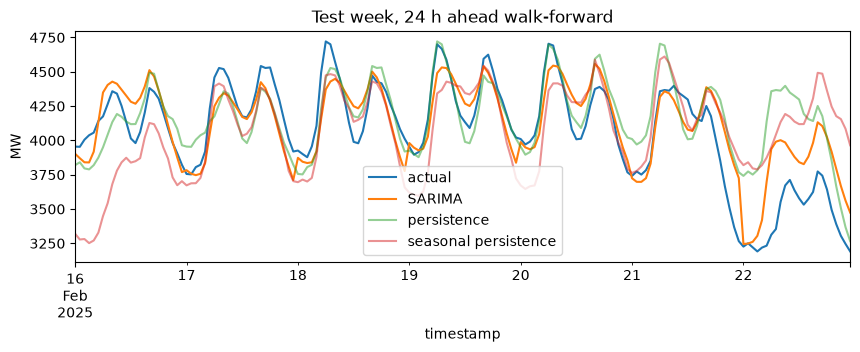

In [7]:
ax = act.plot(figsize=(10,3), label="actual")
pred.plot(ax=ax, label="SARIMA"); pers.plot(ax=ax, label="persistence", alpha=0.5); week.plot(ax=ax, label="seasonal persistence", alpha=0.5)
ax.legend(); ax.set_title("Test week, 24 h ahead walk-forward"); ax.set_ylabel("MW");

Read the skill number, not the plot: a model that cannot beat "tomorrow = today" has learned nothing worth deploying — and on calm weeks persistence is *hard* to beat. This number is the bar every Module 3 learner must clear, on exactly this evaluation. The things SARIMA cannot see — temperature swings, holidays — are precisely where covariates and learned models will earn their keep.


## Self-check


Two promises: SARIMA beats both baselines, and its 24-hour MAE is under 10 % of the mean load. **What you see:** `ALL OK — baseline set: SARIMA 156 MW vs persistence 203 / seasonal 283 MW. Lab 7 makes this yours.`

In [8]:
assert mae_s < min(mae_p, mae_w), "SARIMA should beat both baselines on this winter week"
assert mae_s < 0.10 * act.mean(), "24h MAE above 10% of mean load — something is off"
print(f"ALL OK — baseline set: SARIMA {mae_s:.0f} MW vs persistence {mae_p:.0f} / seasonal {mae_w:.0f} MW. Lab 7 makes this yours.")

ALL OK — baseline set: SARIMA 156 MW vs persistence 203 / seasonal 283 MW. Lab 7 makes this yours.


## 4. What you take to Lab 7

Lab 7 asks for this working method as toolbox code: `persistence` and `seasonal_persistence` are one `shift` each; `walk_forward(y, model_fn, test_start, test_end, horizon=24)` is the loop above with a refit per day and a `model_fn` you pass in — any function of the form `model_fn(train, horizon) -> the next horizon values`, so the same *harness* (the fixed evaluation set-up) later judges every Module 3 learner. All three go into `src/svedala_toolbox/evaluation.py`, where the stubs wait. The deliverable is the number and the honest sentence around it: all three MAEs, and skill against the *better* baseline.